In [1]:
import os
import json
import torch
import random
import torch
import time
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from fontTools.ttLib.tables.C_P_A_L_ import Color
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast  # 混合精度训练
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import torchvision.transforms as transforms
from torchvision.transforms import ColorJitter
import copy

from argparse import ArgumentParser

from datasets import get_data_loaders


from utils import plot_train_history, evaluate_model
from models.efficientnet import efficientnet_b0, efficientnet_v2_m
from models.impr_efficientnet import efficientnet_b0, efficientnet_v2_m, smf_efficientnet_v2_m, EfficientNet_B0_Weights, EfficientNet_V2_M_Weights
# from utils import create_model

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

In [2]:
def create_model(arch):

    model = None

    # Classification model
    if arch == 'EfficientV2':
        num_classes = 3
        model = model = efficientnet_v2_m(weights=EfficientNet_V2_M_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features

        model.classifier = nn.Sequential(
                    nn.Dropout(p=0.3, inplace=True),
                    nn.Linear(in_features, 128),
                    nn.ReLU(inplace=True),
                    nn.BatchNorm1d(128),
                    nn.Linear(128, num_classes)
                )
    elif arch == 'SMFEfficientV2':
        num_classes = 3
        model = model = smf_efficientnet_v2_m(weights=None)
        in_features = model.classifier[1].in_features

        model.classifier = nn.Sequential(
                    nn.Dropout(p=0.3, inplace=True),
                    nn.Linear(in_features, 128),
                    nn.ReLU(inplace=True),
                    nn.BatchNorm1d(128),
                    nn.Linear(128, num_classes)
                )
    
    elif arch == 'EfficientB0':
        num_classes = 3
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features

        model.classifier = nn.Sequential(
                    nn.Dropout(p=0.3, inplace=True),
                    nn.Linear(in_features, 128),
                    nn.ReLU(inplace=True),
                    nn.BatchNorm1d(128),
                    nn.Linear(128, num_classes)
                )

    return model

In [3]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs: int = 50, early_stop_patience: int = 20, save_dir: str = "classifier_model_checkpoints"):
    """Training model"""
    os.makedirs(save_dir, exist_ok=True)

    best_val_acc = 0.0
    best_model = None
    early_stop_counter = 0
    train_history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": []
    } 

    st_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for images, labels, _ in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            train_total += labels.size(0)
            train_correct += (preds == labels).sum().item()

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        train_history["train_loss"].append(epoch_train_loss)
        train_history["train_acc"].append(epoch_train_acc)

        # -------------------------- Eval stage --------------------------
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels, _  in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)

                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        # val performance
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        train_history["val_loss"].append(epoch_val_loss)
        train_history["val_acc"].append(epoch_val_acc)

        scheduler.step(epoch_val_acc)  

        # save best model
        if epoch_val_acc >= best_val_acc:
            best_val_acc = epoch_val_acc
            best_model = copy.deepcopy(model)
            # best_model_path = os.path.join(save_dir, f"best_model_epoch{epoch + 1}_acc{best_val_acc:.4f}.pth")
            # torch.save(model.state_dict(), best_model_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f"Eaily stop step: {early_stop_counter}/{early_stop_patience}")

        # 打印epoch总结
        print(f"Epoch {epoch + 1} - Train loss: {epoch_train_loss:.4f} | accuracy: {epoch_train_acc:.4f} | Val loss: {epoch_val_loss:.4f} | accuracy: {epoch_val_acc:.4f}")
        print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}\n")

        # # 触发早停
        # if early_stop_counter >= early_stop_patience:
        #     print(f" 早停触发（{early_stop_patience}轮无提升），训练结束")
        #     break

    # Training time
    total_time = time.time() - st_time
    print(f"Training time: {total_time // 60:.0f}分{total_time % 60:.0f}s | Best val accuracy:{best_val_acc:.4f}")

    if best_model:
        best_model_path = os.path.join(save_dir, f"best_model_epoch{epoch + 1}_acc{best_val_acc:.4f}.pth")
        torch.save(best_model.state_dict(), best_model_path)
    return train_history, best_model_path


In [4]:
# Load train / val datasets
image_dir = "./data/image"
json_dir = "./data/json"
pad_size = 224
batch_size = 16
num_workers = 8
ng_augment_times = 8

# Create model
arch = "SMFEfficientV2"

lr = 1e-3
weight_decay = 1e-5

epoch = 80
save_dir = "./pcb_model/pcb_model_aug_checkpoints"

In [5]:


train_loader, val_loader, inv_label_map, class_weights = get_data_loaders(
        image_dir=image_dir,
        json_dir=json_dir,
        pad_size=pad_size,
        batch_size=batch_size,
        num_workers=num_workers,
        ng_augment_times=ng_augment_times
    )
print('train len: {}, val len: {}'.format(len(train_loader), len(val_loader)))

正在用PadExtractor处理焊盘数据...


批量提取焊盘与标签:  12%|█▏        | 57/466 [00:00<00:01, 278.90it/s]

警告：样本 00005_1 处理失败，原因：图像 00005_1.png 无包含中心点的焊盘（所有hanpan均不覆盖图像中心）


批量提取焊盘与标签:  54%|█████▍    | 253/466 [00:00<00:00, 274.15it/s]

警告：样本 00109_1 处理失败，原因：图像 00109_1.png 无包含中心点的焊盘（所有hanpan均不覆盖图像中心）


批量提取焊盘与标签:  79%|███████▊  | 366/466 [00:01<00:00, 274.58it/s]

警告：样本 00158_0 处理失败，原因：图像 00158_0.png 无包含中心点的焊盘（所有hanpan均不覆盖图像中心）
警告：样本 00161_1 处理失败，原因：图像 00161_1.png 无包含中心点的焊盘（所有hanpan均不覆盖图像中心）
警告：样本 00163_1 处理失败，原因：图像 00163_1.png 无包含中心点的焊盘（所有hanpan均不覆盖图像中心）
警告：样本 00167_0 处理失败，原因：图像 00167_0.png 无包含中心点的焊盘（所有hanpan均不覆盖图像中心）
警告：样本 00169_1 处理失败，原因：图像 00169_1.png 无包含中心点的焊盘（所有hanpan均不覆盖图像中心）
警告：样本 00174_0 处理失败，原因：图像 00174_0.png 无包含中心点的焊盘（所有hanpan均不覆盖图像中心）


批量提取焊盘与标签: 100%|██████████| 466/466 [00:01<00:00, 288.90it/s]


警告：样本 00216_0 处理失败，原因：JSON文件 ./data/json\00216_0.json 中无有效hanpan标注（circle类型）
警告：样本 00216_1 处理失败，原因：JSON文件 ./data/json\00216_1.json 中无有效hanpan标注（circle类型）
警告：样本 00217_0 处理失败，原因：JSON文件 ./data/json\00217_0.json 中无有效hanpan标注（circle类型）
警告：样本 00217_1 处理失败，原因：JSON文件 ./data/json\00217_1.json 中无有效hanpan标注（circle类型）
警告：样本 00218_0 处理失败，原因：JSON文件 ./data/json\00218_0.json 中无有效hanpan标注（circle类型）
警告：样本 00218_1 处理失败，原因：JSON文件 ./data/json\00218_1.json 中无有效hanpan标注（circle类型）
警告：样本 00219_0 处理失败，原因：JSON文件 ./data/json\00219_0.json 中无有效hanpan标注（circle类型）
警告：样本 00219_1 处理失败，原因：JSON文件 ./data/json\00219_1.json 中无有效hanpan标注（circle类型）
警告：样本 00220_0 处理失败，原因：JSON文件 ./data/json\00220_0.json 中无有效hanpan标注（circle类型）
警告：样本 00220_1 处理失败，原因：JSON文件 ./data/json\00220_1.json 中无有效hanpan标注（circle类型）
警告：样本 00221_0 处理失败，原因：JSON文件 ./data/json\00221_0.json 中无有效hanpan标注（circle类型）
警告：样本 00221_1 处理失败，原因：JSON文件 ./data/json\00221_1.json 中无有效hanpan标注（circle类型）
警告：样本 00222_0 处理失败，原因：JSON文件 ./data/json\00222_0.json 中无有效hanpan标注（circle类型）

In [6]:
# Create model
model = create_model(arch)
model = model.to(device)
print(model)

 cnf.input_channels ,goup 24 24 24
 cnf.input_channels ,goup 24 24 24
 cnf.input_channels ,goup 24 24 24
 cnf.input_channels ,goup 24 96 48
 cnf.input_channels ,goup 48 192 48
 cnf.input_channels ,goup 48 192 48
 cnf.input_channels ,goup 48 192 48
 cnf.input_channels ,goup 48 192 48
 cnf.input_channels ,goup 48 192 80
 cnf.input_channels ,goup 80 320 80
 cnf.input_channels ,goup 80 320 80
 cnf.input_channels ,goup 80 320 80
 cnf.input_channels ,goup 80 320 80
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): SMFMBConv(
        (main_layers): Sequential()
        (branch_layers): Sequential()
        (conv1x1_1): Conv2dNormActivation(
          (0): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1)

In [7]:
# Hyper-params
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.8, patience=3)

In [8]:
# Training models
train_history, best_model_path = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=epoch,
        save_dir=save_dir
    )

Epoch 1/80: 100%|██████████| 30/30 [00:21<00:00,  1.38it/s]


Epoch 1 - Train loss: 0.7057 | accuracy: 0.7063 | Val loss: 1.3026 | accuracy: 0.3482
Current LR: 0.001000



Epoch 2/80: 100%|██████████| 30/30 [00:22<00:00,  1.36it/s]


Epoch 2 - Train loss: 0.4849 | accuracy: 0.8438 | Val loss: 0.7231 | accuracy: 0.5804
Current LR: 0.001000



Epoch 3/80: 100%|██████████| 30/30 [00:21<00:00,  1.40it/s]


...

Epoch 78 - Train loss: 0.1323 | accuracy: 0.9542 | Val loss: 0.1022 | accuracy: 0.9732
Current LR: 0.000018



Epoch 79/80: 100%|██████████| 30/30 [00:20<00:00,  1.43it/s]


Epoch 79 - Train loss: 0.1006 | accuracy: 0.9708 | Val loss: 0.1022 | accuracy: 0.9732
Current LR: 0.000018



Epoch 80/80: 100%|██████████| 30/30 [00:21<00:00,  1.39it/s]


Epoch 80 - Train loss: 0.1198 | accuracy: 0.9625 | Val loss: 0.1019 | accuracy: 0.9732
Current LR: 0.000014

Training time: 53分23s | Best val accuracy:0.9732


 cnf.input_channels ,goup 24 24 24
 cnf.input_channels ,goup 24 24 24
 cnf.input_channels ,goup 24 24 24
 cnf.input_channels ,goup 24 96 48
 cnf.input_channels ,goup 48 192 48
 cnf.input_channels ,goup 48 192 48
 cnf.input_channels ,goup 48 192 48
 cnf.input_channels ,goup 48 192 48
 cnf.input_channels ,goup 48 192 80
 cnf.input_channels ,goup 80 320 80
 cnf.input_channels ,goup 80 320 80
 cnf.input_channels ,goup 80 320 80
 cnf.input_channels ,goup 80 320 80


Evaluation:: 100%|██████████| 7/7 [00:18<00:00,  2.69s/it]

Accuracy: 0.9732

测试集评估结果
测试准确率：0.9732

分类报告（精确率/召回率/F1）：
              precision    recall  f1-score   support

         pre     1.0000    1.0000    1.0000        39
          OK     0.9167    1.0000    0.9565        33
          NG     1.0000    0.9250    0.9610        40

    accuracy                         0.9732       112
   macro avg     0.9722    0.9750    0.9725       112
weighted avg     0.9754    0.9732    0.9733       112


混淆矩阵已保存至：confusion_matrix_aug.png


np.float64(0.9732142857142857)

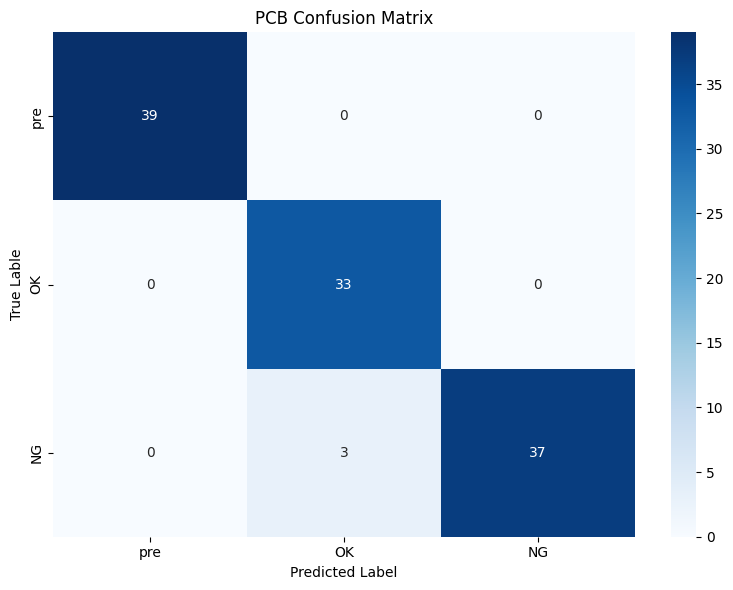

In [9]:
 # best_model = copy.deepcopy(model)
best_model = create_model(arch)
best_model = best_model.to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
evaluate_model(best_model, val_loader, device, inv_label_map)